In [1]:
import pandas as pd
import warnings
import joblib
from sklearn.metrics import make_scorer
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

%run model_research.ipynb
%run splitted_df_validation.ipynb

In [2]:
warnings.filterwarnings("ignore")
df_trades = pd.read_csv('btc_trades_features_04.csv')


In [3]:
df_train, df_test, validation_df = create_train_valid_df(df_trades)

print(f'validation len is: {len(validation_df)}')

2767
1844
train lenght is:1844
test lenght is:923
validation len is: 2767


first iter of training will be a random search of crossed random params with random features, the goal is to find models that can generalize well keeping a consistent recall, the test will be done on the entire test population, once the model will be considered complete the next test for the ecaluation will be a recursive training on the test population keeping small sets aprox 50 to 100 (the goal is to evaluate the model response on changes in market structure and evaluating drowdowns), once the model is trained last test will be test it on entire validation pupulation and recursive test on validation to check for the model consistency

In [4]:
df_trades.columns

Index(['timestamp_rome', 'Open', 'High', 'Low', 'Close', 'Volume', 'Trades',
       'fast_period', 'slow_period', 'macd', 'signal', 'hist', 'atr',
       'Trade_Direction', 'stop_loss', 'macd_slope', 'hist_delta',
       'macd_z_score', 'bars_since_cross', 'vol_ma', 'rvol', 'vwap',
       'dist_to_vwap', 'price_slope', 'donchain_pos', 'upper_wick',
       'wick_ratio', 'sar', 'Rsi_9', 'Rsi_14', 'adx', 'plus_di', 'minus_di',
       'di_diff', 'ema_50_slope', 'ema_200_slope', 'ema_gap',
       'distance_from_ema_50', 'distance_from_ema_200', '1h_ema',
       'htf_trend_diff', 'ema_10', 'ema_20', 'ema_30', 'ema_40', 'ema_50',
       'ema_60', 'ribbon_width', 'ribbon_direction'],
      dtype='object')

In [5]:
features = ['macd_slope', 'hist_delta',
            'macd_z_score', 'bars_since_cross','rvol',
            'dist_to_vwap', 'price_slope', 'donchain_pos',
            'wick_ratio', 'sar', 'Rsi_9', 'Rsi_14', 'adx', 'plus_di', 'minus_di',
            'di_diff','ema_50_slope', 'ema_200_slope', 'ema_gap',
            'distance_from_ema_50', 'distance_from_ema_200','htf_trend_diff',
            'ribbon_width', 'ribbon_direction'
           ]


In [7]:
from sklearn.metrics import fbeta_score
from sklearn.model_selection import TimeSeriesSplit
features_to_use = features
param_distributions_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 1, 10],
    'reg_lambda': [1, 10, 100],
    'scale_pos_weight': [1, 3, 5, 10],
    'tree_method': ['hist', 'auto']
}

scorer = make_scorer(fbeta_score, beta = 0.25, pos_label = 1)
#note: after a first test beta = 0.5 seems to high, search prefered a model with 0.37 prec and 0.97 rec over all
model = XGBClassifier()
tscv = TimeSeriesSplit(n_splits=5, gap=0)
random_search = RandomizedSearchCV(
    estimator = model,
    param_distributions = param_distributions_xgb,
    n_iter = 200,  # Number of parameter combinations to try
    scoring = scorer,  # Use F0.5 score (precision-focused)
    cv = tscv,  # 5-fold cross-validation
    verbose = 1,  # Show progress
    random_state = 42,
    n_jobs = -1,  # Use all available cores
    return_train_score = True  # Track overfitting
)
X_train = df_train[features_to_use]
y_train = df_train['Trades']
X_test = df_test[features_to_use]
y_test = df_test['Trades']
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
test_precision = precision_score(y_test, y_pred, pos_label=1)
test_recall = recall_score(y_test, y_pred, pos_label=1)
print(f"Precision: {test_precision}")
print(f"Recall:    {test_recall}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Precision: 0.5274725274725275
Recall:    0.2857142857142857


this result fit much more to the standard i want to have, next step is to check if the model is consistent in a recursive training over the test sample and check how precision and recall change, the recursive training should start with a warm training

In [8]:
#first let's check how the model predict the test df as it is now
section_df = section_validation(df_test, best_model, features_to_use)

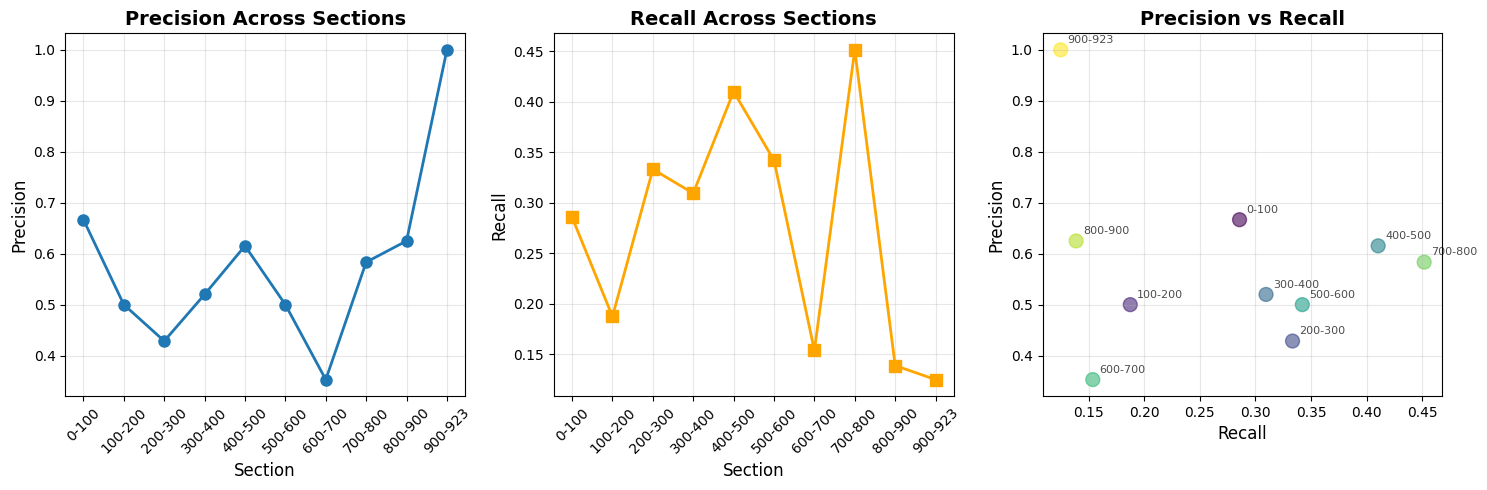

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Precision over sections
axes[0].plot(section_df['section'], section_df['precision'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Section', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision Across Sections', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Plot 2: Recall over sections
axes[1].plot(section_df['section'], section_df['recall'], marker='s', color='orange', linewidth=2, markersize=8)
axes[1].set_xlabel('Section', fontsize=12)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_title('Recall Across Sections', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Plot 3: Precision vs Recall
axes[2].scatter(section_df['recall'], section_df['precision'], s=100, alpha=0.6, 
                c=range(len(section_df)), cmap='viridis')
axes[2].set_xlabel('Recall', fontsize=12)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Add section labels to the scatter plot
for i, row in section_df.iterrows():
    axes[2].annotate(row['section'], (row['recall'], row['precision']), 
                    fontsize=8, alpha=0.7, xytext=(5, 5), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

In [10]:
#model to retrain is best model
model_to_test = best_model
#100 samples per cut
cut_len = 100
cut_num = int(round(len(df_test) / cut_len))
start_idx = 0
end_idx = 0
results_list = []
for cut in range(cut_num):
    
    end_idx = start_idx + cut_len
    current_split = df_test[start_idx:end_idx]
    
    if cut == 0:
        
        precision, recall = test_model(df = current_split, model = model_to_test,
                                       features = features_to_use)
        results_list.append({
            'cut_number': cut,
            'start_idx': start_idx,
            'end_Index': end_idx,
            'precision': precision,
            'recall': recall
        })
        start_idx = end_idx

    else:

        train_split = df_test[:end_idx - cut_len]
        X_train = train_split[features_to_use]
        y_train = train_split['Trades']

        old_model = model_to_test
        old_params = old_model.get_params()
        old_booster = old_model.get_booster()
        model = XGBClassifier(**old_params)
        model.fit(X_train, y_train, xgb_model = old_booster)
        precision, recall = test_model(df = current_split, model = model,
                                       features = features_to_use)
        
        results_list.append({
            'cut_number': cut,
            'start_idx': start_idx,
            'end_Index': end_idx,
            'precision': precision,
            'recall': recall
        })
        start_idx = end_idx

recursive_results_df = pd.DataFrame(results_list)
    
    
        
        




model precision is 0.6666666666666666
model recall is 0.2857142857142857
model precision is 0.25806451612903225
model recall is 0.25
model precision is 0.3181818181818182
model recall is 0.19444444444444445
model precision is 0.5
model recall is 0.5
model precision is 0.6
model recall is 0.3076923076923077
model precision is 0.4146341463414634
model recall is 0.4473684210526316
model precision is 0.43333333333333335
model recall is 0.3333333333333333
model precision is 0.41935483870967744
model recall is 0.41935483870967744
model precision is 0.4090909090909091
model recall is 0.25


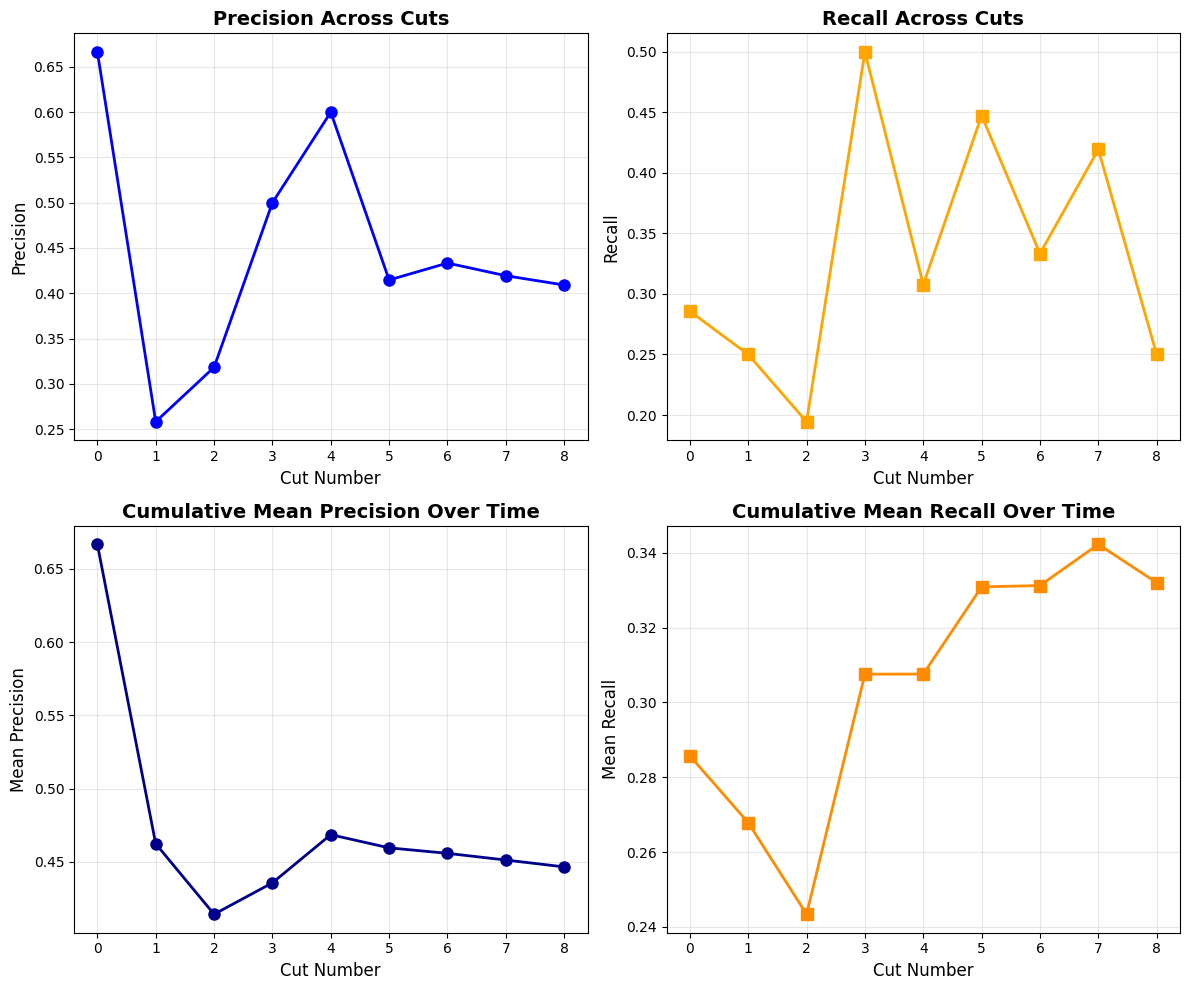

In [11]:

# Create figure with 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Precision over cut_number
axes[0, 0].plot(recursive_results_df['cut_number'], recursive_results_df['precision'], 
             marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Cut Number', fontsize=12)
axes[0, 0].set_ylabel('Precision', fontsize=12)
axes[0, 0].set_title('Precision Across Cuts', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Recall over cut_number
axes[0, 1].plot(recursive_results_df['cut_number'], recursive_results_df['recall'], 
             marker='s', linewidth=2, markersize=8, color='orange')
axes[0, 1].set_xlabel('Cut Number', fontsize=12)
axes[0, 1].set_ylabel('Recall', fontsize=12)
axes[0, 1].set_title('Recall Across Cuts', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Calculate cumulative means
recursive_results_df['cumulative_mean_precision'] = recursive_results_df['precision'].expanding().mean()
recursive_results_df['cumulative_mean_recall'] = recursive_results_df['recall'].expanding().mean()

# Plot 3: Cumulative Mean Precision over cut_number
axes[1, 0].plot(recursive_results_df['cut_number'], recursive_results_df['cumulative_mean_precision'], 
             marker='o', linewidth=2, markersize=8, color='darkblue')
axes[1, 0].set_xlabel('Cut Number', fontsize=12)
axes[1, 0].set_ylabel('Mean Precision', fontsize=12)
axes[1, 0].set_title('Cumulative Mean Precision Over Time', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cumulative Mean Recall over cut_number
axes[1, 1].plot(recursive_results_df['cut_number'], recursive_results_df['cumulative_mean_recall'], 
             marker='s', linewidth=2, markersize=8, color='darkorange')
axes[1, 1].set_xlabel('Cut Number', fontsize=12)
axes[1, 1].set_ylabel('Mean Recall', fontsize=12)
axes[1, 1].set_title('Cumulative Mean Recall Over Time', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
#model to retrain is best model
model_to_use = best_model 
#100 samples per cut
cut_len = 100
cut_num = int(round(len(validation_df) / cut_len))
start_idx = len(df_train)
end_idx = 0
results_list = []
for cut in range(cut_num):
    
    end_idx = start_idx + cut_len
    current_split = df_trades[start_idx:end_idx]
    
    if cut == 0:
        
        precision, recall = test_model(df = current_split, model = model_to_use,
                                       features = features_to_use)
        results_list.append({
            'cut_number': cut,
            'start_idx': start_idx,
            'end_Index': end_idx,
            'precision': precision,
            'recall': recall
        })

    else:

        train_split = df_trades[:end_idx - cut_len]
        X_train = train_split[features_to_use]
        y_train = train_split['Trades']

        old_model = model_to_use
        old_params = old_model.get_params()
        old_booster = old_model.get_booster()
        model = XGBClassifier(**old_params)
        model.fit(X_train, y_train, xgb_model = old_booster)
        precision, recall = test_model(df = current_split, model = model,
                                       features = features_to_use)
        
        results_list.append({
            'cut_number': cut,
            'start_idx': start_idx,
            'end_Index': end_idx,
            'precision': precision,
            'recall': recall
        })
    
    start_idx = end_idx

#end for loop
    

recursive_results_df = pd.DataFrame(results_list)
    
    
        
        




model precision is 0.6666666666666666
model recall is 0.2857142857142857
model precision is 0.4074074074074074
model recall is 0.34375
model precision is 0.3333333333333333
model recall is 0.25
model precision is 0.5609756097560976
model recall is 0.5476190476190477
model precision is 0.5652173913043478
model recall is 0.3333333333333333
model precision is 0.42424242424242425
model recall is 0.3684210526315789
model precision is 0.4166666666666667
model recall is 0.38461538461538464
model precision is 0.4782608695652174
model recall is 0.3548387096774194
model precision is 0.6470588235294118
model recall is 0.3055555555555556
model precision is 0.5
model recall is 0.3611111111111111
model precision is 0.42424242424242425
model recall is 0.4117647058823529
model precision is 0.42857142857142855
model recall is 0.3870967741935484
model precision is 0.5862068965517241
model recall is 0.4594594594594595
model precision is 0.3
model recall is 0.16666666666666666
model precision is 0.5609756

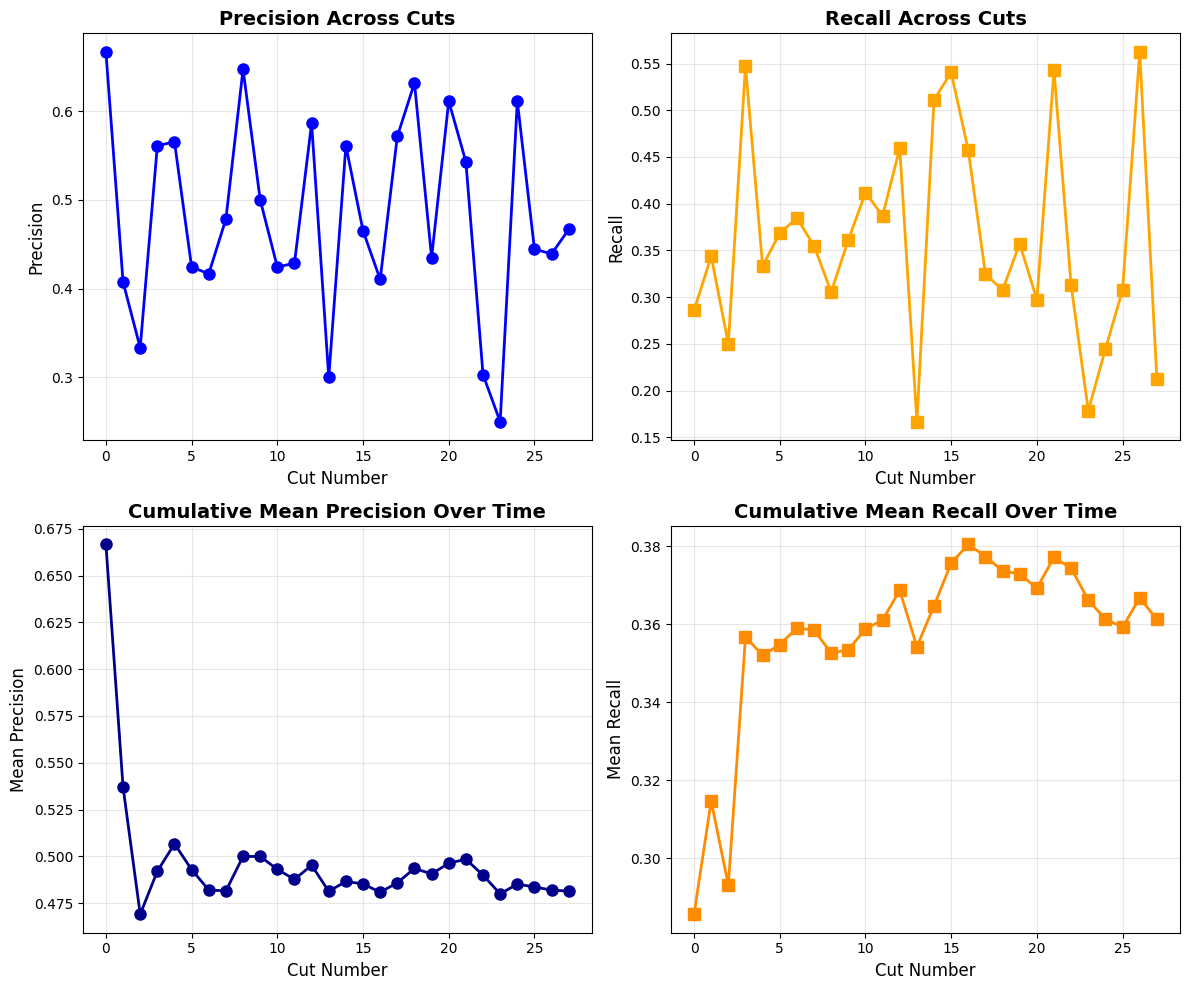

In [13]:

# Create figure with 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Precision over cut_number
axes[0, 0].plot(recursive_results_df['cut_number'], recursive_results_df['precision'], 
             marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Cut Number', fontsize=12)
axes[0, 0].set_ylabel('Precision', fontsize=12)
axes[0, 0].set_title('Precision Across Cuts', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Recall over cut_number
axes[0, 1].plot(recursive_results_df['cut_number'], recursive_results_df['recall'], 
             marker='s', linewidth=2, markersize=8, color='orange')
axes[0, 1].set_xlabel('Cut Number', fontsize=12)
axes[0, 1].set_ylabel('Recall', fontsize=12)
axes[0, 1].set_title('Recall Across Cuts', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Calculate cumulative means
recursive_results_df['cumulative_mean_precision'] = recursive_results_df['precision'].expanding().mean()
recursive_results_df['cumulative_mean_recall'] = recursive_results_df['recall'].expanding().mean()

# Plot 3: Cumulative Mean Precision over cut_number
axes[1, 0].plot(recursive_results_df['cut_number'], recursive_results_df['cumulative_mean_precision'], 
             marker='o', linewidth=2, markersize=8, color='darkblue')
axes[1, 0].set_xlabel('Cut Number', fontsize=12)
axes[1, 0].set_ylabel('Mean Precision', fontsize=12)
axes[1, 0].set_title('Cumulative Mean Precision Over Time', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cumulative Mean Recall over cut_number
axes[1, 1].plot(recursive_results_df['cut_number'], recursive_results_df['cumulative_mean_recall'], 
             marker='s', linewidth=2, markersize=8, color='darkorange')
axes[1, 1].set_xlabel('Cut Number', fontsize=12)
axes[1, 1].set_ylabel('Mean Recall', fontsize=12)
axes[1, 1].set_title('Cumulative Mean Recall Over Time', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

despite precision being lower then target the model seems to be more persistent over time, few more feat. eng. and we can start the second opt. phase.
